# Critical Evaluation of *"A Subset Feature Elimination Mechanism for Intrusion Detection System"*

**Course:** Data Science in Cyber — Final Project (Dr. Uri Itai)
**Author:** Adam Karain (ID 318407889)
**Date:** June 2026

**Source article:** H. Nkiama, S. Z. Mohd Said and M. Saidu, "A Subset Feature Elimination Mechanism for Intrusion Detection System," *IJACSA*, vol. 7, no. 4, 2016 — [PDF](https://thesai.org/Downloads/Volume7No4/Paper_19-A_Subset_Feature_Elimination_Mechanism_for_Intrusion_Detection_System.pdf)
**Reference implementation:** [CynthiaKoopman/Network-Intrusion-Detection](https://github.com/CynthiaKoopman/Network-Intrusion-Detection)
**Dataset:** NSL-KDD — [defcom17/NSL_KDD](https://github.com/defcom17/NSL_KDD) (copies of the required files are included in `data/`)

## 1. Introduction

Network Intrusion Detection Systems (IDS) classify network traffic as benign or malicious. The article evaluated here argues that most of the 41 NSL-KDD features are redundant, and proposes a two-stage feature-selection pipeline — a univariate ANOVA F-test filter (`SelectPercentile`) followed by Recursive Feature Elimination (RFE) around a decision tree — applied separately to each of the four attack classes (DoS, Probe, R2L, U2R) framed as a binary problem (normal vs. that class). The authors report that 11–15 selected features are enough to reach roughly **99.7–99.9% accuracy, precision, recall and F-measure**, while cutting training time by an order of magnitude.

The problem matters: an IDS that is accurate but slow cannot keep up with modern traffic volumes, and an IDS that misses attacks is worse than none, because it creates false confidence. Feature selection promises to address the first concern without sacrificing the second — *if* the reported detection quality is real.

This notebook reproduces the article's pipeline and tests its three explicit claims, plus one question the article leaves open:

* **C1** — the two-stage feature selection (ANOVA filter + RFE) improves classification performance (the article's Table IV vs. Table V).
* **C2** — the per-class detectors reach ≈99.7–99.9% accuracy, precision, recall and F-measure.
* **C3** — feature selection cuts training time by roughly an order of magnitude.
* **Q4** (our extension, *not* a claim the article makes) — does the per-class evaluation reflect how the detector behaves on the benchmark's held-out test set, which deliberately contains attack types absent from training?

**What the article evaluates on — a point that is easy to get wrong.** The article's Methodology (Step 5) states that *"the test data was used to make prediction of our model and for evaluation,"* and that *"a 10-fold cross-validation was performed during all the process."* Its confusion matrices (Table VI) have row totals of 7,460 / 2,421 / 2,885 / 67 — exactly the official `KDDTest+` class sizes (we confirm this in §3). So the test set **is** used. The decisive question is therefore not *whether* `KDDTest+` was touched, but *how*: a 10-fold cross-validation that pools each distribution does not exercise the train→test novelty gap that NSL-KDD was built around. We evaluate every model two ways — under a cross-validation protocol that pools a single distribution (reproducing the article), and under the benchmark's intended held-out protocol (fit on `KDDTrain+`, score on the official `KDDTest+`). For the article's own per-class pipeline (§7) we add a third diagnostic — cross-validating the test set itself — to show exactly how the published numbers arise. Throughout, we report uncertainty, because the rare classes have very few test records.

## 2. Setup

Fixed random seeds are used everywhere so that every result in this notebook is reproducible.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectPercentile, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             accuracy_score, f1_score, fbeta_score,
                             matthews_corrcoef, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
DATA_DIR = Path("data")
sns.set_theme(style="whitegrid", palette="muted")

# Silence two benign sklearn warnings that would otherwise clutter the output:
# constant one-hot columns inside a per-class subset (ANOVA F-test) and the
# occasional logistic-regression convergence notice. Neither affects results.
warnings.filterwarnings("ignore", message="Features .* are constant")
warnings.filterwarnings("ignore", message="invalid value encountered in divide")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

## 3. Data Loading

NSL-KDD is distributed as headerless text files; the official column names are listed in `Field Names.csv`. Each record describes one TCP/UDP/ICMP connection with 41 features, an attack-type label, and a `difficulty` score. We load the full training set (`KDDTrain+`) and the official test set (`KDDTest+`).

In [2]:
feature_names = pd.read_csv(DATA_DIR / "Field Names.csv", header=None)[0].tolist()
COLUMNS = feature_names + ["label", "difficulty"]


def load_split(file_name):
    """Read one NSL-KDD file and attach the official column names."""
    return pd.read_csv(DATA_DIR / file_name, header=None, names=COLUMNS)


train = load_split("KDDTrain+.txt")
test = load_split("KDDTest+.txt")

In [3]:
print(f"Training set: {train.shape[0]:,} rows x {train.shape[1]} columns\n"
      f"Test set:     {test.shape[0]:,} rows x {test.shape[1]} columns")

Training set: 125,973 rows x 43 columns
Test set:     22,544 rows x 43 columns


**First discrepancy.** The article reports 126,620 training and 22,850 test records (its Tables I–III), but the official files contain **125,973** and **22,544**. The difference is small, yet it shows that the article's bookkeeping does not match the published data — a useful reminder to verify everything that follows.

In [4]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


**Columns and index.** The index is a plain row number, which is appropriate: each record is an independent connection summary, so no natural key exists. The column names follow the official field list (duration, protocol, service, flag, byte counts, content counters, and 2-second/host-based traffic-window statistics), so the schema is sensible and matches the documentation. `label` holds the attack type and `difficulty` is evaluation metadata, not a traffic feature — both are excluded from the design matrix later.

In [5]:
train.dtypes.value_counts().rename("columns").to_frame()

,columns
int64,24
float64,15
object,4


**Feature types.** Of the 43 columns, 38 features are numeric (counters, rates in [0, 1], and binary indicators stored as integers), three are nominal strings (`protocol_type`, `service`, `flag` — encoded in §5), and the remaining two object/int columns are `label` and `difficulty`. There are no date or free-text columns.

### 3.1 Attack categories

The 39 attack-type labels are grouped into four standard categories (DoS, Probe, R2L, U2R), following the article and the NSL-KDD documentation. The mapping below also covers the attack types that appear **only** in the test set.

In [6]:
ATTACK_CATEGORY = {
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS", "smurf": "DoS",
    "teardrop": "DoS", "apache2": "DoS", "udpstorm": "DoS", "processtable": "DoS",
    "worm": "DoS", "mailbomb": "DoS",
    "satan": "Probe", "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "mscan": "Probe", "saint": "Probe",
    "guess_passwd": "R2L", "ftp_write": "R2L", "imap": "R2L", "phf": "R2L",
    "multihop": "R2L", "warezmaster": "R2L", "warezclient": "R2L", "spy": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "snmpguess": "R2L", "snmpgetattack": "R2L",
    "httptunnel": "R2L", "sendmail": "R2L", "named": "R2L",
    "buffer_overflow": "U2R", "loadmodule": "U2R", "rootkit": "U2R", "perl": "U2R",
    "sqlattack": "U2R", "xterm": "U2R", "ps": "U2R",
    "normal": "normal",
}

train["category"] = train["label"].map(ATTACK_CATEGORY)
test["category"] = test["label"].map(ATTACK_CATEGORY)
assert train["category"].notna().all() and test["category"].notna().all()

In [7]:
CATEGORY_ORDER = ["normal", "DoS", "Probe", "R2L", "U2R"]
category_counts = pd.concat(
    [train["category"].value_counts(), test["category"].value_counts()],
    axis=1, keys=["train", "test"]).loc[CATEGORY_ORDER]
category_counts

,train,test
category,,
normal,67343,9711
DoS,45927,7460
Probe,11656,2421
R2L,995,2885
U2R,52,67


The two rare classes are strikingly small: **R2L has 995 and U2R only 52 training records**, against 67,343 normal connections. Note also the proportions: R2L is 0.8% of the training set but 12.8% of the test set. We return to this imbalance in the EDA.

In [8]:
novel_attacks = sorted(set(test["label"]) - set(train["label"]))
novel_share = test.loc[test["category"] != "normal", "label"].isin(novel_attacks).mean()
print(f"{len(novel_attacks)} attack types appear only in the test set:\n{novel_attacks}\n"
      f"They account for {novel_share:.1%} of all attack records in KDDTest+.")

17 attack types appear only in the test set:
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']
They account for 29.2% of all attack records in KDDTest+.


This is **by design**. Tavallaee et al. (2009), who created NSL-KDD, built `KDDTest+` so that a meaningful share of its attacks are types never seen during training, precisely to measure whether a detector generalizes beyond the attack catalog it was trained on. An evaluation that folds `KDDTest+` into cross-validation rather than holding it out silently skips this question — keep this in mind for Section 7.

### 3.2 Data quality inspection

In [9]:
print(f"Missing values (both splits): {int(train.isna().sum().sum() + test.isna().sum().sum())}\n"
      f"Duplicate training rows: {train.duplicated().sum()}\n"
      f"Duplicate test rows: {test.duplicated().sum()}")

Missing values (both splits): 0
Duplicate training rows: 0
Duplicate test rows: 0


No missing values and no duplicates — as expected, since removing the massive duplication of the original KDD'99 was the main reason NSL-KDD was created. No imputation or deduplication is needed.

In [10]:
constant_features = train[feature_names].nunique().loc[lambda counts: counts == 1].index.tolist()
print(f"Constant features in the training set: {constant_features}")

Constant features in the training set: ['num_outbound_cmds']


`num_outbound_cmds` equals zero in every record of both splits, so it carries no information and is dropped. Together with `label`, `category` and `difficulty`, this is the only column removed before modelling; there are no duplicated feature columns (all pairwise-identical checks come up empty, see the redundancy analysis in §4.4 for *near*-duplicates).

### 3.3 Temporal analysis

NSL-KDD contains **no timestamps**: records are connection summaries in no chronological order, so a time-based split or trend analysis is impossible. The temporal dimension instead lives *inside* the features: `count`, `srv_count` and the error-rate features are computed over a 2-second window preceding each connection, and the `dst_host_*` features over a 100-connection window per destination host. Checking these against domain knowledge:

In [11]:
window_features = ["count", "srv_count", "serror_rate", "same_srv_rate", "dst_host_count"]
train.groupby("category")[window_features].mean().round(2).loc[CATEGORY_ORDER]

,count,srv_count,serror_rate,same_srv_rate,dst_host_count
category,,,,,
normal,22.52,27.69,0.01,0.97,147.43
DoS,178.09,32.66,0.75,0.19,244.60
Probe,77.05,10.94,0.05,0.70,145.20
R2L,1.30,2.46,0.01,1.00,89.04
U2R,5.81,1.27,0.04,0.93,47.77


The window features behave exactly as networking knowledge predicts: **DoS** floods produce many connections per window (`count` ≈ 178, eight times the normal rate) with a high SYN-error rate (`serror_rate` ≈ 0.75 — half-open connections, the signature of a SYN flood); **Probe** scans also drive `count` up while spreading across services; **R2L and U2R look almost identical to normal traffic** in these aggregates, because they consist of a few application-layer sessions rather than high-volume floods. This already hints at which classes will be hard to detect.

## 4. Exploratory Data Analysis

### 4.1 Class balance and prevalence

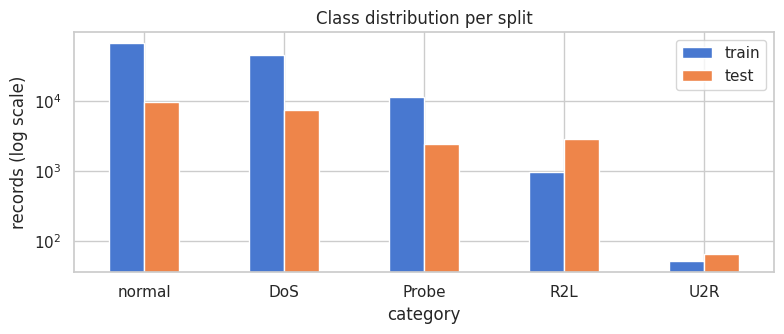

In [12]:
ax = category_counts.plot.bar(figsize=(8, 3.5), logy=True, rot=0)
ax.set_ylabel("records (log scale)")
ax.set_title("Class distribution per split")
plt.tight_layout()
plt.show()

In [13]:
prevalence = category_counts.div(category_counts.sum()).mul(100).round(2)
prevalence.rename(columns=lambda split: f"{split} (%)")

,train (%),test (%)
category,,
normal,53.46,43.08
DoS,36.46,33.09
Probe,9.25,10.74
R2L,0.79,12.80
U2R,0.04,0.30


**Class-imbalance analysis.** Attack prevalence differs sharply between splits and classes:

* **U2R is 0.04% of the training data** — 52 records to learn from. No classifier can characterize "privilege escalation" from 52 examples; this is a sampling problem in the dataset itself.
* **R2L is 0.8% of training but 12.8% of the test set** (and most test R2L types are new). The class prior shifts by a factor of ~16 between fit and deployment.
* The real-world meaning: in production traffic, attacks are rare events, so plain accuracy is dominated by the majority class. NSL-KDD's test set is the opposite extreme (57% attacks), which is equally unrepresentative; either way, accuracy alone is uninformative — §7 shows a U2R detector with 99.5% accuracy that misses two-thirds of U2R attacks.

**Did the authors address this?** No. The article reports accuracy as its headline metric, uses no class weighting or resampling, and never mentions the train/test prevalence gap. This is the first substantive weakness of the source.

### 4.2 Continuous features and outliers

The traffic counters span many orders of magnitude, so they are plotted on a log scale.

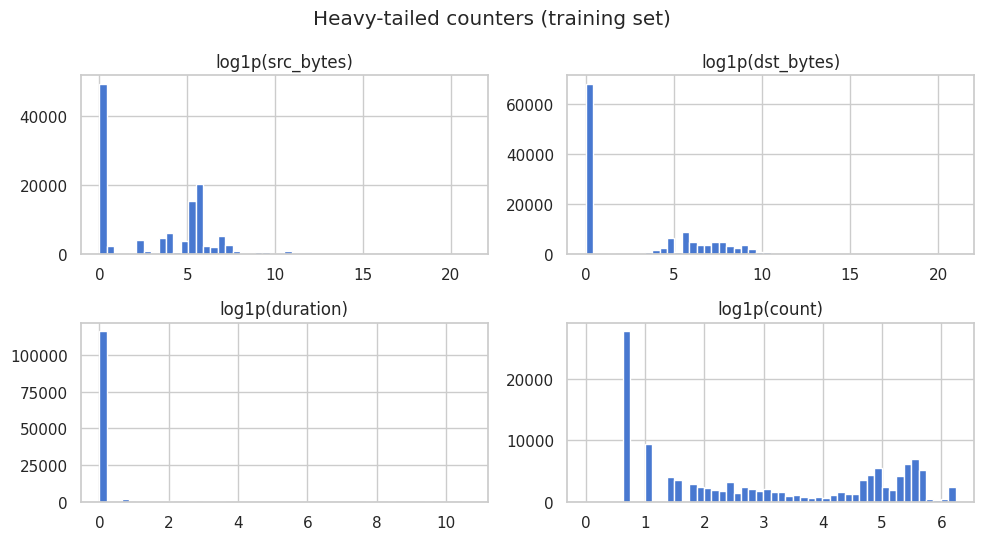

In [14]:
heavy_tailed = ["src_bytes", "dst_bytes", "duration", "count"]
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5))
for feature, ax in zip(heavy_tailed, axes.ravel()):
    ax.hist(np.log1p(train[feature]), bins=50)
    ax.set_title(f"log1p({feature})")
fig.suptitle("Heavy-tailed counters (training set)")
plt.tight_layout()
plt.show()

In [15]:
outlier_summary = train[heavy_tailed].describe(percentiles=[0.5, 0.99]).T
outlier_summary[["50%", "99%", "max"]].astype(int)

,50%,99%,max
src_bytes,44,54540,1379963888
dst_bytes,0,25519,1309937401
duration,0,9590,42908
count,14,511,511


**Outlier analysis.** The distributions are zero-inflated and extremely heavy-tailed: the median of `src_bytes` is 44 bytes while the maximum is ≈1.4 **GB** — more than four orders of magnitude above the 99th percentile. Crucially, these outliers are **not measurement noise but attack behavior** (flood volumes, large exfiltration payloads, very long sessions), so removing or winsorizing them would delete the signal we want to detect. Instead the heavy tails inform two methodological choices: a rank-based correlation measure (§4.4) and the decision in §5 to *test* a `log1p` transform for the scale-sensitive linear model (which we adopt only if it measurably helps).

### 4.3 Categorical features (crosstab analysis)

In [16]:
pd.crosstab(train["protocol_type"], train["category"], normalize="columns").round(3)[CATEGORY_ORDER]

category,normal,DoS,Probe,R2L,U2R
protocol_type,,,,,
icmp,0.019,0.062,0.355,0.0,0.000
tcp,0.796,0.919,0.502,1.0,0.942
udp,0.185,0.019,0.143,0.0,0.058


The protocol mix per class matches domain knowledge: DoS is mostly TCP (the `neptune` SYN flood) with a visible ICMP share (the `smurf` echo-reply flood); probes use ICMP sweeps far more than any other class; R2L and U2R are almost purely TCP, as expected for application-layer attacks (logins, shells).

In [17]:
pd.crosstab(train["flag"], train["category"], normalize="columns").round(3)[CATEGORY_ORDER]

category,normal,DoS,Probe,R2L,U2R
flag,,,,,
OTH,0.000,0.000,0.003,0.000,0.000
REJ,0.040,0.123,0.246,0.000,0.000
RSTO,0.003,0.026,0.007,0.046,0.019
RSTOS0,0.000,0.000,0.009,0.000,0.000
RSTR,0.002,0.002,0.187,0.005,0.000
S0,0.005,0.748,0.013,0.000,0.000
S1,0.005,0.000,0.000,0.001,0.000
S2,0.002,0.000,0.000,0.001,0.000
S3,0.001,0.000,0.000,0.003,0.000


The TCP status flag is even more telling: **79% of DoS connections end in `S0`** (SYN sent, nothing came back — a half-open connection, the textbook SYN-flood signature), probes concentrate in `REJ`/`RSTR` (rejected or reset scans), while **R2L traffic ends in `SF` (a normally completed connection) 97% of the time — exactly like benign traffic**. The categorical features confirm the §3.3 picture: volumetric attacks are easy, stealthy ones are not.

### 4.4 Correlation analysis

**Choice of correlation measure.** We studied three options:

* **Pearson** measures *linear* association and assumes approximately well-behaved (finite-variance, outlier-free) variables. With features spanning nine orders of magnitude, a single extreme record can dominate the statistic.
* **Spearman** is Pearson on ranks: it captures any *monotonic* relationship, is invariant to monotone transforms (so `src_bytes` and `log1p(src_bytes)` give identical values) and is robust to the outliers documented above.
* **Kendall** estimates the probability of concordance; it is preferred for small samples or when many ties distort Spearman. With *n* = 125,973 its extra robustness adds little, at a higher computational cost.

**Decision: Spearman** is the primary measure — the data are heavy-tailed, outlier-rich and full of saturated rates, which violates Pearson's working assumptions, while the sample is far too large for Kendall to add value. Pearson is shown once below to demonstrate the difference, and one more caveat applies: with *n* ≈ 126,000, even ρ = 0.01 is "statistically significant," so we reason about **effect size (practical significance), not p-values**.

In [18]:
pearson = train["src_bytes"].corr(train["dst_bytes"])
spearman = train["src_bytes"].corr(train["dst_bytes"], method="spearman")
print(f"src_bytes vs dst_bytes -- Pearson: {pearson:+.3f}, Spearman: {spearman:+.3f}")

src_bytes vs dst_bytes -- Pearson: +0.000, Spearman: +0.700


A textbook illustration: Pearson reports essentially no association because a handful of gigabyte-scale records crush the covariance, while Spearman reveals the strong monotonic relationship one expects between request and response sizes. Conclusions below rely on Spearman.

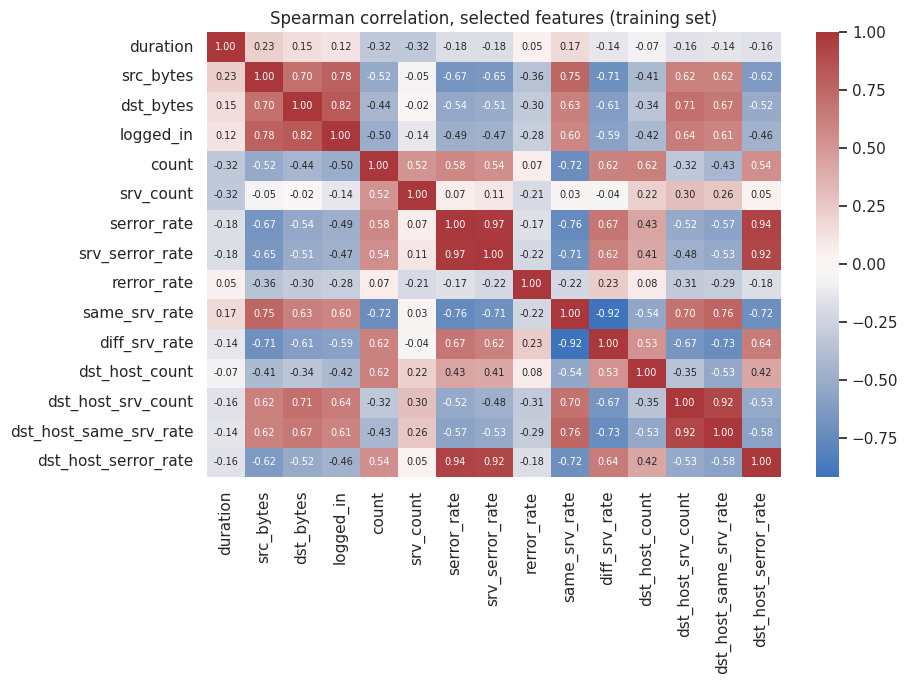

In [19]:
correlation_features = ["duration", "src_bytes", "dst_bytes", "logged_in", "count",
                        "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
                        "same_srv_rate", "diff_srv_rate", "dst_host_count",
                        "dst_host_srv_count", "dst_host_same_srv_rate",
                        "dst_host_serror_rate"]
spearman_matrix = train[correlation_features].corr(method="spearman")
plt.figure(figsize=(9.5, 7))
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            annot_kws={"size": 7})
plt.title("Spearman correlation, selected features (training set)")
plt.tight_layout()
plt.show()

In [20]:
upper_triangle = spearman_matrix.where(np.triu(np.ones_like(spearman_matrix, dtype=bool), k=1))
redundant_pairs = upper_triangle.stack().loc[lambda corr: corr.abs() > 0.9].round(3)
redundant_pairs.rename("Spearman rho").to_frame()

Spearman rho
serror_rate        srv_serror_rate                0.973
                   dst_host_serror_rate           0.936
srv_serror_rate    dst_host_serror_rate           0.919
same_srv_rate      diff_srv_rate                 -0.920
dst_host_srv_count dst_host_same_srv_rate         0.919

**Redundancy in the system.** Several feature pairs are near-duplicates: the SYN-error rate is measured three times at different aggregation levels (`serror_rate`, `srv_serror_rate`, `dst_host_serror_rate`, pairwise ρ ≈ 0.92–0.97), `same_srv_rate` and `diff_srv_rate` are near mirror images (ρ = −0.92), and `dst_host_srv_count` largely repeats `dst_host_same_srv_rate` (ρ = 0.92).

*How to spot it:* exactly as done here — screen the correlation matrix for |ρ| > 0.9, or use variance-inflation factors / hierarchical clustering on 1 − |ρ| for groups rather than pairs.

*How to tackle it:* keep one representative per cluster, use regularization (for linear models), or let a wrapper method such as RFE prune the copies. Redundancy barely hurts tree *accuracy*, but it dilutes feature-importance scores, slows training, and inflates the dimensionality that the article uses to motivate feature selection in the first place — so the article's premise that 41 features contain substantial redundancy is, in fairness, **correct**.

In [21]:
numeric_features = [name for name in feature_names
                    if name not in ["protocol_type", "service", "flag", "num_outbound_cmds"]]
is_attack_train = (train["category"] != "normal").astype(int)
target_correlation = train[numeric_features].corrwith(is_attack_train, method="spearman")
target_correlation.reindex(target_correlation.abs().sort_values(ascending=False).index).head(10).round(3).rename("Spearman rho vs is_attack").to_frame()

,Spearman rho vs is_attack
dst_bytes,-0.752
same_srv_rate,-0.735
src_bytes,-0.711
logged_in,-0.690
dst_host_srv_count,-0.686
diff_srv_rate,0.677
serror_rate,0.655
dst_host_same_srv_rate,-0.651
dst_host_serror_rate,0.638
srv_serror_rate,0.630


The strongest monotone associations with the attack label are all consistent with the crosstabs: attacks rarely receive a substantial response payload (`dst_bytes`, ρ = −0.75 — floods and scans get nothing back), their windows are spread across many different services (`same_srv_rate` negative, `diff_srv_rate` positive), they rarely reach a logged-in state (`logged_in`, ρ = −0.69), and they trip the SYN-error counters. Two caveats: these are |ρ| ≈ 0.6–0.75 effects — strong and practically significant, not just statistically so — and they describe a training distribution dominated by `neptune` and `smurf`. Whether they transfer to unseen attack types is precisely what Section 7 tests.

## 5. Feature Engineering

To stay faithful to the article, the design matrix uses exactly the two transformations the article describes (Steps 1–2): one-hot encoding and standardization. Two further options are *tested* rather than assumed, and adopted only if the evidence supports them.

1. **Dropping non-features** — `num_outbound_cmds` (constant, §3.2), `label`/`category` (targets) and `difficulty` (evaluation metadata; using it would leak information about how hard a record is to classify).
2. **One-hot encoding** for `protocol_type`, `service`, `flag` — these are *nominal* with no order, so integer/label encoding would fabricate a false ordering; target encoding was rejected because it injects label information into features and risks leakage. With 84 categories in total, one-hot keeps the design matrix at a manageable 121 columns, sparse and fully interpretable.
3. **Standardization (z-scores)** — required by the gradient-based logistic regression; harmless for trees. It is applied **inside each model's pipeline** so the scaler is fitted only on that fold's training rows; fitting it on the full data (or, worse, on the test set, as the reference implementation does) leaks distributional information.

**A transform we tested and did *not* adopt: `log1p`.** The heavy-tailed counters (§4.2) are an obvious candidate for log compression, so we measured its effect on the only model that is not scale-invariant — logistic regression — under the held-out protocol. The skewness table below shows the transform does what it advertises on the *inputs*; the experiment after it shows it does **not** improve the *model*.

In [22]:
log_transformed = train[heavy_tailed].apply(np.log1p)
pd.DataFrame({"skewness (raw)": train[heavy_tailed].skew(),
              "skewness (log1p)": log_transformed.skew()}).round(1)

,skewness (raw),skewness (log1p)
src_bytes,190.7,0.3
dst_bytes,290.1,0.5
duration,11.9,5.3
count,1.5,0.1


`log1p` reduces the skewness of the byte counters from ≈190–290 to below 1. That improves the *distribution of the inputs* — but the question for a model is whether it improves *predictions*, so we test it directly rather than assert it.

In [23]:
CATEGORICAL = ["protocol_type", "service", "flag"]
NON_FEATURES = ["num_outbound_cmds", "label", "difficulty", "category"]


def build_features(frame, log_compress=False):
    """Drop non-features and one-hot encode; optionally log-compress the heavy tails."""
    features = frame.drop(columns=NON_FEATURES)
    if log_compress:
        features[heavy_tailed] = features[heavy_tailed].apply(np.log1p)
    return pd.get_dummies(features, columns=CATEGORICAL, dtype=float)


def align_to(reference, frame):
    """Match a design matrix to the training columns (unseen categories become zero)."""
    return frame.reindex(columns=reference.columns, fill_value=0.0)


# Faithful design matrix: one-hot only (standardization happens inside the pipelines).
X_train = build_features(train)
X_test = align_to(X_train, build_features(test))
y_train = (train["category"] != "normal").astype(int)
y_test = (test["category"] != "normal").astype(int)
print(f"Design matrices -- train: {X_train.shape}, test: {X_test.shape}\n"
      f"Service categories present only in training: "
      f"{sorted(set(train['service']) - set(test['service']))}")

Design matrices -- train: (125973, 121), test: (22544, 121)
Service categories present only in training: ['aol', 'harvest', 'http_2784', 'http_8001', 'red_i', 'urh_i']


In [24]:
def held_out_recall(make_features):
    """Fit logistic regression with given features on KDDTrain+, score recall on KDDTest+."""
    train_design = make_features(train)
    test_design = align_to(train_design, make_features(test))
    model = Pipeline([("scale", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    model.fit(train_design, y_train)
    scores = model.predict_proba(test_design)[:, 1]
    return pd.Series({"recall": recall_score(y_test, model.predict(test_design)),
                      "ROC-AUC": roc_auc_score(y_test, scores)})


pd.DataFrame({"one-hot only": held_out_recall(lambda f: build_features(f)),
              "+ log1p": held_out_recall(lambda f: build_features(f, log_compress=True))}).round(4)

,one-hot only,+ log1p
recall,0.6231,0.6284
ROC-AUC,0.7799,0.7638


**Decision: drop `log1p`.** On the held-out test set it moves logistic-regression recall by less than a percentage point and *lowers* ROC-AUC; the tree models are invariant to any monotonic transform by construction, so it cannot help them at all. An unsupported "it can only help" claim is exactly the kind of thing this project is meant to catch, so we keep the faithful one-hot + standardize matrix and report the negative result honestly.

**Feature selection** is deferred to Section 7, because the two-stage ANOVA + RFE selector *is* the article's contribution and deserves its own treatment. **Dimensionality reduction** (e.g. PCA) is deliberately not used: an IDS analyst must be able to read *why* a connection was flagged ("high SYN-error rate to port 80"), and linear combinations of 121 columns destroy that interpretability while offering trees no accuracy benefit.

## 6. Model Training

**Two evaluation protocols.** Everything in this project hinges on this distinction:

* **Protocol A (a single distribution):** stratified 80/20 random split *within* `KDDTrain+`. Train and validation records come from the same distribution — statistically equivalent to the article's 10-fold cross-validation, which is why it reproduces the article's flattering numbers.
* **Protocol B (the intended benchmark):** fit on all of `KDDTrain+`, evaluate on the official `KDDTest+`, where 29% of attack records belong to never-seen attack types.

**No leakage.** Each model is a `Pipeline` whose `StandardScaler` is fitted only on the rows the model trains on (the 80% fit split under Protocol A, all of `KDDTrain+` under Protocol B). The test set never participates in fitting the scaler.

**Three models** are trained as binary detectors (normal vs. attack): logistic regression (a linear baseline), a decision tree (the article's classifier), and a random forest (a stronger ensemble). All share the same preprocessing and seeds.

In [25]:
def evaluate_predictions(y_true, y_pred, y_score):
    """Compute all classification metrics used in this project."""
    return pd.Series({
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "F2": fbeta_score(y_true, y_pred, beta=2),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_score),
    })

In [26]:
def recall_ci(y_true, y_pred, n_boot=2000):
    """Bootstrap 95% confidence interval for recall (resampling the positive records)."""
    rng = np.random.default_rng(RANDOM_STATE)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    positives = np.flatnonzero(y_true == 1)
    draws = [(y_pred[rng.choice(positives, positives.size, replace=True)] == 1).mean()
             for _ in range(n_boot)]
    return np.percentile(draws, [2.5, 97.5])

In [27]:
def make_pipeline(make_model):
    """Standardize inside the pipeline so the scaler never sees held-out rows."""
    return Pipeline([("scale", StandardScaler()), ("clf", make_model())])


def fit_and_evaluate(make_model):
    """Return a Protocol-B-fitted pipeline plus its Protocol A and Protocol B metric rows."""
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)
    protocol_a = make_pipeline(make_model).fit(X_fit, y_fit)
    a_row = evaluate_predictions(y_val, protocol_a.predict(X_val),
                                 protocol_a.predict_proba(X_val)[:, 1])
    protocol_b = make_pipeline(make_model).fit(X_train, y_train)
    b_row = evaluate_predictions(y_test, protocol_b.predict(X_test),
                                 protocol_b.predict_proba(X_test)[:, 1])
    return protocol_b, a_row, b_row

In [28]:
MODEL_FACTORIES = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": lambda: DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=100, n_jobs=2,
                                                    random_state=RANDOM_STATE),
}

fitted_models, protocol_a_rows, protocol_b_rows = {}, {}, {}
for model_name, factory in MODEL_FACTORIES.items():
    fitted_models[model_name], protocol_a_rows[model_name], protocol_b_rows[model_name] = \
        fit_and_evaluate(factory)

In [29]:
pd.DataFrame(protocol_a_rows).T.round(4)

,accuracy,precision,recall,F1,F2,MCC,ROC-AUC
Logistic Regression,0.9723,0.9766,0.9636,0.9700,0.9662,0.9444,0.9963
Decision Tree,0.9985,0.9980,0.9987,0.9984,0.9986,0.9970,0.9985
Random Forest,0.9990,0.9993,0.9986,0.9989,0.9987,0.9980,1.0000


Under Protocol A every model looks superb — the tree-based models exceed 99.6% on *every* metric, fully consistent with the article's reported numbers and with the dozens of NSL-KDD tutorials that stop here.

In [30]:
pd.DataFrame(protocol_b_rows).T.round(4)

,accuracy,precision,recall,F1,F2,MCC,ROC-AUC
Logistic Regression,0.7535,0.9173,0.6231,0.7421,0.6658,0.5581,0.7799
Decision Tree,0.8117,0.9665,0.6932,0.8074,0.7348,0.6664,0.8309
Random Forest,0.7765,0.9687,0.6277,0.7618,0.6752,0.6167,0.9583


In [31]:
protocol_b_recall_ci = {name: recall_ci(y_test, model.predict(X_test)).round(3)
                        for name, model in fitted_models.items()}
pd.DataFrame(protocol_b_recall_ci, index=["recall 2.5%", "recall 97.5%"]).T

,recall 2.5%,recall 97.5%
Logistic Regression,0.615,0.632
Decision Tree,0.685,0.701
Random Forest,0.619,0.636


Under Protocol B the picture changes completely: **accuracy drops by 18–22 points and recall collapses to 0.62–0.69**, while precision stays above 0.91 — the models almost never cry wolf, they simply *miss a third of the attacks*. The same models, the same preprocessing, the same seeds; the only difference is evaluating on data whose attack mix the models have not memorized. Note how misleading accuracy alone would be here (still 0.75–0.81), and how MCC (0.56–0.67 vs. 0.95–1.00) exposes the gap honestly. The bootstrap intervals above are narrow (the test set has thousands of attacks), so this gap is not sampling noise — unlike the rare-class results in §7, where it partly is.

### 6.1 Evaluation metrics: definitions and justification

For a confusion matrix with true/false positives and negatives (TP, FP, TN, FN), an "attack" being the positive class:

* **Accuracy** = (TP+TN)/N — share of correct decisions. Reported *only* because the article uses it as its headline number; with 46–57% attack prevalence across splits it is not absurd here, but it hides the FN/FP composition entirely and would be meaningless at realistic (low) attack rates.
* **Precision** = TP/(TP+FP) — of the alerts raised, how many are real. Low precision means alert fatigue: analysts drown in false alarms and start ignoring the console.
* **Recall (detection rate)** = TP/(TP+FN) — of the real attacks, how many we caught. Every FN is an undetected intrusion; in security this is usually the costlier error.
* **F1** = harmonic mean of precision and recall — a single balance number, used for cross-model comparison.
* **F2** = F-beta with β = 2, weighting recall twice as heavily as precision. We report it because the IDS cost structure is asymmetric: a missed breach (FN) costs incident response, data loss and legal exposure, while a false alarm (FP) costs analyst minutes. β = 2 encodes "recall matters roughly twice as much."
* **MCC** (Matthews correlation) — correlation between predicted and true labels using all four confusion-matrix cells; 1 is perfect, 0 is chance. It is the most honest single number under class imbalance and cannot be gamed by majority-class guessing.
* **ROC-AUC** — probability that a random attack scores above a random normal record; threshold-free, it separates *ranking quality* from *threshold choice*, which proves diagnostic below.

**Omitted metrics, and why:** regression metrics (MAE/MSE/RMSE/R²) do not apply to a classification task; specificity is redundant given the false-positive analysis in §8; F0.5 encodes the opposite (precision-heavy) cost structure to the IDS use case.

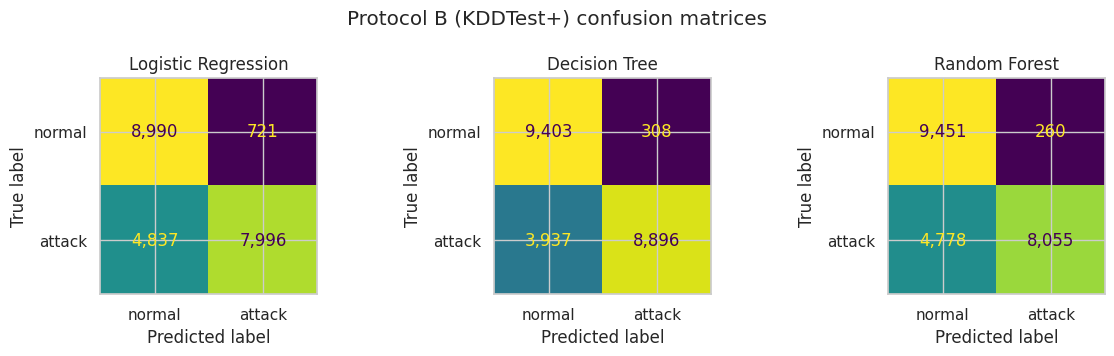

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for (model_name, model), ax in zip(fitted_models.items(), axes):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, colorbar=False,
                                          display_labels=["normal", "attack"],
                                          values_format=",d")
    ax.set_title(model_name)
fig.suptitle("Protocol B (KDDTest+) confusion matrices")
plt.tight_layout()
plt.show()

The confusion matrices make the failure mode concrete: false positives stay in the hundreds (260–770 out of 9,711 normal records), while **false negatives run into the thousands** (3,900–4,800 out of 12,833 attacks). An IDS with this profile feels reassuringly quiet — and is blind to a third of real attacks.

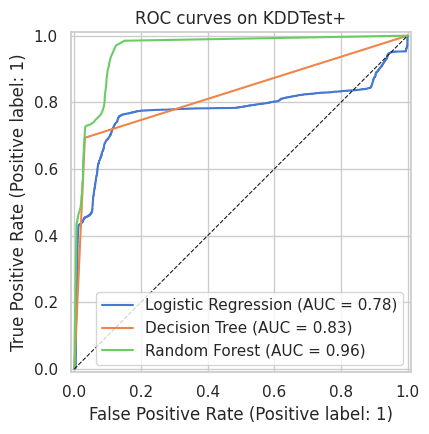

In [33]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("ROC curves on KDDTest+")
plt.tight_layout()
plt.show()

An instructive split result: the random forest *ranks* attacks well (AUC ≈ 0.96) even though its default-threshold recall is only ≈0.63. Its scores carry real signal, but the 0.5 threshold — implicitly calibrated on the training distribution — sits in the wrong place once the attack mix shifts. Lowering the threshold would trade false positives for recall along this curve; under distribution shift, **threshold calibration breaks before ranking does**. The decision tree, by contrast, offers no such ranking reserve (AUC ≈ 0.83): its problem is the model, not the threshold.

## 7. Reproducing the Article's Per-Class Protocol

The article's pipeline, per attack class (Methodology, Steps 1–5): keep normal traffic plus one attack category; one-hot encode and standardize; run a **univariate ANOVA F-test filter (`SelectPercentile`) and then RFE around a decision tree** to select 11–15 features; fit a decision tree; and evaluate with *"the test data ... for prediction"* under *"10-fold cross-validation ... during all the process."* We reproduce this faithfully — ANOVA filter included, and the article's own per-class feature counts (DoS 12, Probe 15, R2L 13, U2R 11 from its Table IV) — inside a single leakage-free `Pipeline` so that scaling and selection are refitted on each fold's training rows. We declare one compute deviation: the cross-validation that stands in for the article's protocol is run on a stratified 12,000-record subsample with RFE `step=10` (feature ranks are stable under both).

We then score each class **three ways** to separate "did the test set get used?" from "was the novelty gap exercised?":

* **CV on training data** — the article's in-distribution protocol.
* **CV on the test data** — what the reference implementation actually does (`cross_val_score` on `KDDTest+`); this still pools the distribution, so novel attacks land in the model's own training folds.
* **Held-out** — fit on `KDDTrain+`, predict `KDDTest+` once, as Tavallaee et al. intended; reported with a bootstrap 95% recall interval.

In [34]:
def class_subsets(category):
    """Binary (normal vs. one attack class) design matrices for train and test."""
    in_train = train["category"].isin(["normal", category]).values
    in_test = test["category"].isin(["normal", category]).values
    return (X_train.loc[in_train], (train.loc[in_train, "category"] == category).astype(int),
            X_test.loc[in_test], (test.loc[in_test, "category"] == category).astype(int))


def paper_pipeline(n_features):
    """The article's faithful per-class pipeline: scale -> ANOVA filter -> RFE -> decision tree."""
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
    return Pipeline([("scale", StandardScaler()),
                     ("anova", SelectPercentile(f_classif, percentile=50)),
                     ("rfe", RFE(tree, n_features_to_select=n_features, step=10)),
                     ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))])

In [35]:
ARTICLE_FEATURE_COUNTS = {"DoS": 12, "Probe": 15, "R2L": 13, "U2R": 11}
folds = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)


def reproduce_class(category):
    """Score the article's pipeline three ways for one attack class."""
    X_tr, y_tr, X_te, y_te = class_subsets(category)
    pipe = paper_pipeline(ARTICLE_FEATURE_COUNTS[category])

    sample = train_test_split(X_tr, y_tr, train_size=12_000, stratify=y_tr,
                              random_state=RANDOM_STATE)[0::2]  # (X_sample, y_sample)
    cv_train = cross_val_score(pipe, *sample, cv=folds, n_jobs=2).mean()
    cv_test = cross_val_score(pipe, X_te, y_te, cv=folds, n_jobs=2).mean()

    pipe.fit(X_tr, y_tr)
    held_out = evaluate_predictions(y_te, pipe.predict(X_te), pipe.predict_proba(X_te)[:, 1])
    low, high = recall_ci(y_te, pipe.predict(X_te))
    selected = X_tr.columns[pipe.named_steps["anova"].get_support()][
        pipe.named_steps["rfe"].support_].tolist()
    summary = pd.Series({"CV acc (train)": cv_train, "CV acc (test)": cv_test,
                         "held-out acc": held_out["accuracy"], "held-out recall": held_out["recall"],
                         "recall 95% CI": f"{low:.1%}-{high:.1%}", "held-out MCC": held_out["MCC"]})
    return summary, selected

In [36]:
ATTACK_CLASSES = ["DoS", "Probe", "R2L", "U2R"]
paper_rows, selected_features = {}, {}
for attack_class in ATTACK_CLASSES:
    paper_rows[attack_class], selected_features[attack_class] = reproduce_class(attack_class)
pd.DataFrame(paper_rows).T

,CV acc (train),CV acc (test),held-out acc,held-out recall,recall 95% CI,held-out MCC
DoS,0.996417,0.995516,0.880904,0.736595,72.7%-74.6%,0.771026
Probe,0.994,0.991922,0.884273,0.552251,53.2%-57.1%,0.604378
R2L,0.99775,0.977215,0.795967,0.110919,9.9%-12.3%,0.292622
U2R,0.998833,0.996625,0.994989,0.343284,22.4%-44.8%,0.529163


**The central result of this project.** Side by side with the article's Table IV:

| Class | Article (Table IV): acc / prec / rec (%) | Ours, CV on **train** (%) | Ours, CV on **test** (%) | Ours, **held-out** KDDTest+: acc / recall (%) |
|---|---|---|---|---|
| DoS | 99.90 / 99.69 / 99.79 | 99.6 | 99.6 | 88.1 / 73.7 |
| Probe | 99.80 / 99.37 / 99.37 | 99.4 | 99.2 | 88.4 / 55.2 |
| R2L | 99.88 / 97.40 / 97.41 | 99.8 | **97.7** | 79.6 / **11.1** |
| U2R | 99.95 / 99.70 / 99.69 | 99.9 | 99.7 | 99.5 / **34.3** |

Three facts follow, and together they correct the central claim:

1. **The article's numbers are real and reproducible.** Cross-validation on the training distribution returns the same ≈99.6–99.9% the article reports.
2. **The test set *was* used — but cross-validated, not held out, which is exactly why the reported numbers are so high.** Running 10-fold CV *on `KDDTest+` itself* (what the third-party reference implementation does) reproduces the article almost exactly — R2L **97.7%** against the article's claimed **97.4%**. Together with confusion-matrix totals equal to the `KDDTest+` class sizes (§3), this shows the test set is genuinely involved; it is simply pooled by cross-validation, so the novel attacks it contains leak into the model's own training folds instead of being held out.
3. **Under the benchmark's intended held-out protocol the detectors collapse.** R2L recall falls to **11.1%** (95% CI ≈ 10–12%) against a claimed 97.4%, and U2R's seemingly perfect 99.5% *accuracy* coexists with **34.3% recall** — and, with only 67 U2R test records, a 95% interval spanning roughly ±11 points (see table). The article's evaluation answers "can the model re-recognize attacks drawn from its own distribution?"; its conclusions speak about detecting intrusions in general.

In [37]:
ARTICLE_DOS_FEATURES = {"diff_srv_rate", "dst_bytes", "dst_host_serror_rate",
                        "dst_host_srv_serror_rate", "flag_S0", "rerror_rate",
                        "same_srv_rate", "service_ecr_i", "service_http",
                        "service_private", "src_bytes", "wrong_fragment"}
overlap = ARTICLE_DOS_FEATURES & set(selected_features["DoS"])
print(f"DoS features selected here:\n{sorted(selected_features['DoS'])}\n\n"
      f"Overlap with the article's Table VIII: {len(overlap)} of "
      f"{len(ARTICLE_DOS_FEATURES)} -- {sorted(overlap)}")

DoS features selected here:
['count', 'dst_host_diff_srv_rate', 'dst_host_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_diff_host_rate', 'dst_host_srv_rerror_rate', 'dst_host_srv_serror_rate', 'flag_SF', 'logged_in', 'same_srv_rate', 'service_ecr_i', 'wrong_fragment']

Overlap with the article's Table VIII: 5 of 12 -- ['dst_host_serror_rate', 'dst_host_srv_serror_rate', 'same_srv_rate', 'service_ecr_i', 'wrong_fragment']


**Was the feature engineering meaningful?** Yes — with an important caveat. Mathematically, the ANOVA filter scores each feature by between-class F-statistic and RFE then prunes by impurity contribution; the two-stage selector recovers 5 of the article's 12 DoS features (the overlap is printed above), and several of the rest are close cousins — it keeps `flag_SF` where the article keeps `flag_S0`, two complementary encodings of whether a connection completed normally or hung half-open (the SYN-flood signature). From a cybersecurity standpoint the shared features are exactly the signatures an analyst would name: the SYN-error window rates (`dst_host_serror_rate`, `dst_host_srv_serror_rate`), `service_ecr_i` (ICMP echo replies — `smurf`), `wrong_fragment` (`teardrop`) and `same_srv_rate`. The selection is *interpretable and domain-plausible*, and it confirms the article's premise that NSL-KDD carries substantial redundancy (§4.4).

The caveat: these are signatures of the **specific attacks present in the training catalog**. A feature set optimized to separate `neptune` from normal traffic has no reason to flag an `apache2` request flood — which is exactly the failure §8 documents. **Additional features that could plausibly improve performance:** payload-derived statistics (byte-entropy, header anomalies), per-source aggregates over longer horizons (failed logins per hour, fan-out), and sequence features across connections — none of which exist in NSL-KDD, which is itself an argument for modern datasets (CICIDS, UNSW-NB15).

### 7.1 Reproducibility and a note on attribution

The original authors released **no code**, so no official implementation exists to run. The repository linked here, `CynthiaKoopman/Network-Intrusion-Detection`, is an **independent third-party reproduction**, not the authors' own work; we use it only as corroborating evidence for how the article's numbers can arise, and we are careful not to attribute its exact choices to the authors as established fact. What we can state with confidence rests on the article itself: its text says the test data was used with 10-fold cross-validation throughout, and its confusion-matrix totals equal the `KDDTest+` class sizes. What we can *demonstrate* is that cross-validating the test set reproduces the published metrics (the "CV on test" column above), whereas a genuine held-out split does not. Whether the authors intended this pooling or simply did not isolate the held-out split, the consequence for the published conclusions is the same. Everything in this notebook, by contrast, is reproducible: pinned dependencies, vendored data, fixed seeds, and one clearly labelled protocol per number.

## 8. Error Analysis

We analyze the random forest (the strongest Protocol B model).

In [38]:
rf_predictions = pd.Series(fitted_models["Random Forest"].predict(X_test), index=test.index)
attacks = test[test["category"] != "normal"]
recall_by_category = (rf_predictions.loc[attacks.index].groupby(attacks["category"])
                      .mean().loc[ATTACK_CLASSES].round(3).rename("recall"))
recall_by_category.to_frame()

,recall
category,
DoS,0.827
Probe,0.729
R2L,0.040
U2R,0.119


In [39]:
is_novel = attacks["label"].isin(novel_attacks)
attack_pred = rf_predictions.loc[attacks.index]
novel_low, novel_high = recall_ci(is_novel.astype(int).values, attack_pred.values)
print(f"Recall on attack types seen in training: {attack_pred[~is_novel].mean():.1%}\n"
      f"Recall on novel attack types:            {attack_pred[is_novel].mean():.1%} "
      f"(95% CI {novel_low:.1%}-{novel_high:.1%})")

Recall on attack types seen in training: 76.5%
Recall on novel attack types:            29.6% (95% CI 28.1%-31.2%)


In [40]:
missed_attacks = attacks.loc[rf_predictions.loc[attacks.index] == 0, "label"]
missed_attacks.value_counts().head(10).rename("missed records").to_frame()

,missed records
label,
guess_passwd,1231
warezmaster,837
processtable,678
mscan,653
snmpguess,331
apache2,303
mailbomb,293
snmpgetattack,178
httptunnel,130


In [41]:
normal_test = test["category"] == "normal"
false_positive_rate = rf_predictions[normal_test].mean()
print(f"False-positive rate on normal traffic: {false_positive_rate:.2%} "
      f"({int(rf_predictions[normal_test].sum()):,} of {int(normal_test.sum()):,} records)")

False-positive rate on normal traffic: 2.68% (260 of 9,711 records)


**Patterns in the errors.**

1. **Errors concentrate where training data was scarce or absent.** Recall is acceptable for DoS and Probe, and catastrophic for R2L and U2R — the classes with 995 and 52 training records and the highest share of novel types.
2. **Novel attack types are the dominant failure**, with recall well below half of that on known types (29.6% vs. 76.5%). Even *novel DoS* attacks (`apache2`, `processtable`, `mailbomb` — all in the top missed list) evade a model that detects known DoS almost perfectly: the model learned the signatures of `neptune` and `smurf`, not the concept "denial of service."
3. **The single most-missed attack is `guess_passwd`** (password guessing): per §4.3, R2L sessions complete normally (`flag = SF`) and look like routine logins in every window statistic. `snmpgetattack` is literally indistinguishable from benign SNMP traffic in these features.

**Cybersecurity implications.** The errors are not random — they are exactly the attacks a real adversary would choose: credential attacks and anything invented after the training data was collected. A deployed version of this IDS would be quietest precisely where it is weakest.

**The FP/FN trade-off.** At the default threshold the forest produces ≈2.7% false positives (≈260 alerts per 9,711 benign connections) against ≈4,800 missed attacks. The costs are asymmetric: an FP costs minutes of analyst triage, an FN can cost a breach. The ROC analysis (§6.1) shows the score ranking supports a more recall-favorable threshold; in production one would tune the threshold against an explicit cost matrix (and the F2 metric already encodes that preference), accepting more triage work to shrink the blind spot.

## 9. Conclusions

**Key findings.**

1. The article's pipeline is fully reproducible, and its numbers are *real*: cross-validating within a single distribution returns the same ≈99.6–99.9% figures.
2. The article **does** use `KDDTest+` (its text and its confusion-matrix totals confirm it) — but it cross-validates the test set rather than holding it out, which is why cross-validation *on the test data* reproduces its R2L figure (97.7% vs. a claimed 97.4%). The flaw is the evaluation **protocol**, not an untouched test set.
3. Under the benchmark's intended held-out protocol, the same per-class detectors fall to ≈74% recall for DoS, ≈55% for Probe, **≈11% for R2L and ≈34% for U2R** — the last two with wide bootstrap intervals, because those classes have 2,885 and only 67 test records. The gap is driven, in order, by novel attack types (29% of test attacks), extreme class imbalance (52 U2R / 995 R2L training records), and selected features that encode signatures of specific known attacks.

**Verdict on the claims.**

| Claim | Verdict |
|---|---|
| C1 — feature selection improves performance | **Confirmed in-distribution**: with the ANOVA + RFE selector, ≈11–15 of 121 columns preserve (and in the article's Table IV vs. V slightly improve) performance within the distribution. We add the caveat the article omits — this was never tested under distribution shift. |
| C2 — ≈99.7–99.9% accuracy/precision/recall | **Reproducible but not generalizable**: the figures hold under cross-validation (on train *or* test), but the per-class binary framing and pooled CV evaluate re-recognition of known-distribution attacks, not held-out detection, where R2L recall is ≈11% (95% CI ≈10–12%) vs. the claimed 97.4%. |
| C3 — faster training with fewer features | **Confirmed**: fitting on ≈11–15 features is roughly an order of magnitude faster, consistent with the article's Table IX. |
| Q4 — sound basis for a practical IDS (our extension) | **Not supported**: a per-class binary detector that misses ≈90% of held-out R2L attacks and most novel variants is not deployable as-is; the article does not actually claim deployability, so this is our assessment, not a refutation of the authors. |

**Lessons learned.** The evaluation protocol matters more than the model: three very different classifiers all looked near-perfect within one distribution and all dropped sharply on the held-out split. Cross-validation answers "did I fit this distribution?", not "will this work on next year's attacks?". Accuracy under class imbalance can be arbitrarily flattering (a U2R detector with 99.5% accuracy misses two-thirds of attacks); MCC, F2 and held-out per-class recall tell the truth — and on rare classes they must be reported *with* confidence intervals.

**Strengths of the original work:** a clearly stated and genuinely important problem; standard, transparent tools (scikit-learn, NSL-KDD); a faithful, interpretable feature-selection result that independent runs largely re-derive; and an honest, confirmed speed benefit.

**Weaknesses:** the evaluation pools the official test set through cross-validation instead of holding it out, so the train→test novelty gap — the benchmark's whole purpose — is never exercised; class imbalance is neither discussed nor addressed; accuracy is the headline metric; the per-class binary framing flatters the problem; and the dataset bookkeeping (record counts) is internally inconsistent.

**Suggestions for future improvement:** report held-out `KDDTest+`/`KDDTest-21` as the primary benchmark; address imbalance with class weights or resampling; tune decision thresholds against an explicit FP/FN cost matrix; add an anomaly-detection branch (e.g. Isolation Forest on normal traffic) to catch never-seen attack families; calibrate scores; and validate on modern traffic datasets (CICIDS2017/2018, UNSW-NB15).

---

*Final remark.* This project is a case study in why reproduction work matters: every individual number in the article checks out, and the headline conclusion still does not generalize. The claims are not fabricated — they are measured under a protocol that does not test what the conclusions assert.